   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

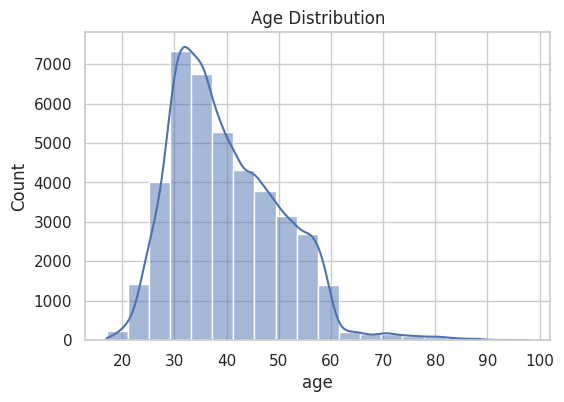

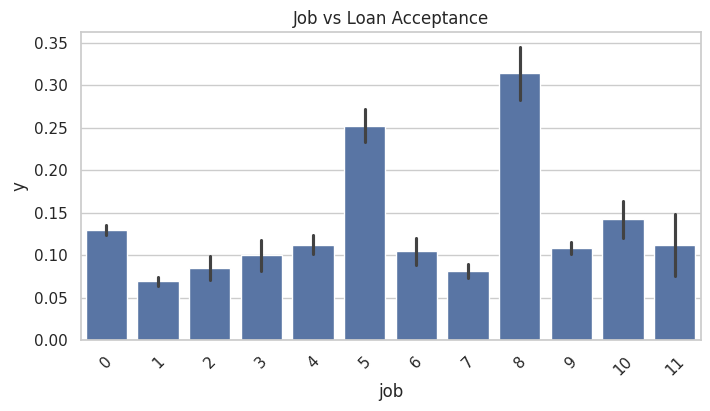

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# =========================
# TASK 5: BANK MARKETING / LOAN ACCEPTANCE PREDICTION
# =========================

#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")

# =========================
#  LOAD DATASET
# =========================
# Upload "bank.csv"

df = pd.read_csv("bank.csv", sep=";")
print(df.head())

# =========================
#  DATA EXPLORATION
# =========================
print(df.shape)
print(df.info())
print(df.isnull().sum())

# =========================
#  BASIC CLEANING
# =========================
# Convert target column ('y') into 0/1

df["y"] = df["y"].map({"yes": 1, "no": 0})

# =========================
#  ENCODE CATEGORICAL FEATURES
# =========================
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

# =========================
#  DATA VISUALIZATION
# =========================

# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Job vs Target
plt.figure(figsize=(8,4))
sns.barplot(x="job", y="y", data=df)
plt.title("Job vs Loan Acceptance")
plt.xticks(rotation=45)
plt.show()

# =========================
#  SPLIT DATA
# =========================
X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
#  MODEL TRAINING
# =========================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# =========================
#  PREDICTIONS
# =========================
y_pred = model.predict(X_test)

# =========================
#  EVALUATION
# =========================

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
#  CONCLUSION
# =========================
print("""
CONCLUSION:

A Logistic Regression model was used to predict whether customers accept a loan offer.
Data preprocessing included encoding categorical variables.

The model helps banks understand customer behavior and improve marketing strategies.
""")